# **Librerias y Funciones**

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import persim
import math
import random
import pandas as pd

from ripser import ripser
from persim import plot_diagrams

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor 
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.base import clone

In [27]:
#Mapeo estandar
def standard_map(p, theta, K):

    p_sig = (p + K * np.sin(theta)) % (2 * np.pi)
    theta_sig = (theta + p_sig) % (2 * np.pi)
    return p_sig, theta_sig

#Generar una sola orbita mediante el modelo de Chirikov-Taylor
def chirikov_taylor(p_0, theta_0, K, num_puntos):
    p_orbita=[]
    theta_orbita=[]
    
    for _ in range(0,num_puntos):
        p_sig, theta_sig = standard_map(p_0, theta_0, K)
        p_orbita.append(p_sig)
        theta_orbita.append(theta_sig)
    
        p_0=p_sig
        theta_0=theta_sig
    
    x_rect=[]
    y_rect=[]
    
    for i in range(0,num_puntos):
        x_rect.append(p_orbita[i]*np.cos(theta_orbita[i]))
        y_rect.append(p_orbita[i]*np.sin(theta_orbita[i]))
        
    return np.vstack([x_rect,y_rect]).T

#Generar una sección de Poincaré
def sec_poincare(p_iniciales, theta_iniciales, K, num_orbitas, num_puntos):
    poincare=[]
    for i in range(num_orbitas):
        aux=chirikov_taylor(p_iniciales[i], theta_iniciales[i], K, num_puntos)
        poincare.append(aux)

    return np.array(poincare)

#Entrenamiento y evaluacion del ajuste polinomial usual
def entrenar_evaluar_polinomial(X, y, grado=2):
    modelo = Pipeline([
        ("poly_features", PolynomialFeatures(degree=grado, include_bias=False)),
        ("std_scaler", StandardScaler()), 
        ("lin_reg", LinearRegression())
    ])

    scores = cross_val_score(modelo, X, y, scoring="neg_mean_squared_error", cv=5)
    rmse_scores = np.sqrt(-scores)

    print(f"RMSE promedio: {rmse_scores.mean():.4f}")
    
    return modelo.fit(X, y)

#Entrenamiento del ajuste polinomial segmentado
def entrenar_modelo_segmentado(X, y, umbral_k=1.0):
    # Separamos los datos según el umbral_k
    idx_bajo = y < umbral_k
    idx_alto = y >= umbral_k
    
    # Ajuste bajo
    modelo_bajo = Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("reg", HuberRegressor())
    ])
    
    #Ajuste alto
    modelo_alto = Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("reg", HuberRegressor())
    ])
    
    modelo_bajo.fit(X[idx_bajo], y[idx_bajo])
    modelo_alto.fit(X[idx_alto], y[idx_alto])
    
    return modelo_bajo, modelo_alto

#Evaluación del ajuste polinomial segmentado
def evaluar_precision_segmentadol(X, y, mod_bajo, mod_alto, umbral_k=1.0):
    # Separamos los datos según el umbral_k
    idx_bajo = y < umbral_k
    idx_alto = y >= umbral_k

    # Predecir los datos según el umbral_k
    pred_bajo = mod_bajo.predict(X[idx_bajo])
    pred_alto = mod_alto.predict(X[idx_alto])
    
    #Combinar todas las predicciones y valores reales
    y_total = np.concatenate([y[idx_bajo], y[idx_alto]])
    preds_total = np.concatenate([pred_bajo, pred_alto])

    rmse_global = np.sqrt(mean_squared_error(y_total, preds_total))
    
    print(f"RMSE Global Segmentado: {rmse_global:.4f}")
    return rmse_global

#Graficar ajuste polinomial usual
def graficar_ajuste_polinomial(X, y, modelo, grado, titulo, eje_x):
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = modelo.predict(X_range)

    plt.figure(figsize=(10, 6))
    
    plt.scatter(X, y, color='#2AA58B', alpha=0.8, label='Datos')
    
    plt.plot(X_range, y_pred, color='#804C80', linewidth=3, 
             label=f'Ajuste Polinomial de Grado {grado}')
    
    plt.title(titulo, fontsize=14)
    plt.xlabel(eje_x, fontsize=12)
    plt.ylabel('Valor de $K$', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.savefig("Ajuste Polinomial Chirikov.png", bbox_inches='tight')
    plt.show()

#Graficar ajuste polinomial segmentado
def graficar_regresion_segmentada(X, y, mod_bajo, mod_alto, umbral_k=1.0):

    plt.figure(figsize=(10, 6))
    
    idx_bajo = y < umbral_k
    idx_alto = y >= umbral_k
    plt.scatter(X[idx_bajo], y[idx_bajo], color='#2AA58B', alpha=0.8, label=f'Datos Estables (K < {umbral_k})')
    plt.scatter(X[idx_alto], y[idx_alto], color='#D49AD4', alpha=0.8, label=f'Datos Caóticos (K >= {umbral_k})')
    
    x_min, x_max = X.min(), X.max()
    x_linea = np.linspace(x_min, x_max, 500).reshape(-1, 1)
    

    preds_linea_bajo = mod_bajo.predict(x_linea)
    
    mask_bajo = preds_linea_bajo < umbral_k
    plt.plot(x_linea[mask_bajo], preds_linea_bajo[mask_bajo], 
             color='#226457', linewidth=3, label='Polinomio Régimen Bajo')
    

    preds_linea_alto = mod_alto.predict(x_linea)
    mask_alto = preds_linea_alto >= umbral_k
    plt.plot(x_linea[mask_alto], preds_linea_alto[mask_alto], 
             color='#804C80', linewidth=3, label='Polinomio Régimen Alto')
    
    plt.axhline(y=umbral_k, color='#D6AF51', linestyle='--', alpha=1, label=f'Umbral K = {umbral_k}', linewidth=3)
    plt.title('Ajuste Polinomial Segmentado usando Huber Regressor', fontsize=15)
    plt.xlabel('Distancia Wasserstein', fontsize=13)
    plt.ylabel('Valor de K', fontsize=13)
    plt.grid(True, alpha=0.5)
    plt.legend(loc='best')

    plt.savefig("Ajuste Polinomial Segmentado Chirikov.png", bbox_inches='tight')
    plt.show()

#Función para compara predicciones entre ambos módelos
def comparar_predicciones_caos(X_nuevas, K_valores, modelo_global, modelo_bajo, modelo_alto, umbral_k=1.0):
    predicciones_global = []
    predicciones_segmentado = []
    regimen_asignado = []
    
    X_nuevas = np.array(X_nuevas).reshape(-1, 1)
    
    for i, x in enumerate(X_nuevas):
        #Predicción del ajuste polinomial usual
        pred_g = modelo_global.predict(x.reshape(1, -1))[0]
        predicciones_global.append(pred_g)
        
        #Predicción del ajuste segmentado

        #Usamos la prediccipon del ajsute usual para discernir si usar el ajuste bajo o el alto en el segmentado
        if pred_g < umbral_k:
            pred_s_bajo = modelo_bajo.predict(x.reshape(1, -1))[0]
            predicciones_segmentado.append(pred_s_bajo)
            regimen_asignado.append("Estable")
        else:
            pred_s_alto = modelo_alto.predict(x.reshape(1, -1))[0]
            predicciones_segmentado.append(pred_s_alto)
            regimen_asignado.append("Caótica")
            
    #Estructurar los resultados en un DataFrame
    tabla_comparativa = pd.DataFrame({
        'Sección de Poincaré': [f"Sección {i+1}" for i in range(len(X_nuevas))],
        'Distancia de Wasserstein': X_nuevas.ravel(),
        'Predicción Usual': np.round(predicciones_global, 4),
        'Predicción Segmentada': np.round(predicciones_segmentado, 4),
        'Estado Detectado': regimen_asignado,
        'Valor de Caos Real': K_valores
    })
    
    return tabla_comparativa

#Funcion para graficar el diagrama de persistencia
def graficar_diag(dgms, Titulo, guardado):
    fig, ax = plt.subplots(figsize=(7, 7))

    max_val = max([np.nanmax(d[np.isfinite(d)]) for d in dgms if d.size > 0]) * 1.1
    ax.plot([0, max_val], [0, max_val], '--', color='black', alpha=1)

    x_vals = np.linspace(0, max_val, 100)
    ax.fill_between(x_vals, 0, x_vals, color='lightgray', alpha=0.8)

    colors = ['#2AA58B', '#804C80', '#27ae60', '#c0392b']
    labels = ['$H_0$', '$H_1$', '$H_2$', '$H_3$']

    for i, dgm in enumerate(dgms):
        if dgm.size > 0:
            clean_dgm = dgm[np.isfinite(dgm).all(axis=1)]

            ax.scatter(clean_dgm[:, 0], clean_dgm[:, 1],
                      color=colors[i],
                      label=labels[i],
                      s=80,
                      alpha=0.8,
                      edgecolors='none')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xlim(-0.03*max_val, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel('Nacimiento', fontsize=15)
    ax.set_ylabel('Muerte', fontsize=15)
    ax.set_title(f'{Titulo}', fontsize=15)
    ax.legend()
    plt.savefig(f'{guardado}', bbox_inches='tight')
    plt.show()

# **Datos y Calculo de los Diagramas de Persistencia**

In [3]:
n=200
K_valores=np.linspace(0, 3, n)
num_puntos = 100
num_orbitas= 20

p_min,p_max=0,2*np.pi
theta_min,theta_max=0,2*np.pi

p_iniciales=[]
theta_iniciales=[]
for j in range(n):
  p_iniciales.append(np.random.uniform(p_min,p_max,num_orbitas))
  theta_iniciales.append(np.random.uniform(theta_min,theta_max,num_orbitas))

muestras_modelo=[]
for i in range(n):
    aux=sec_poincare(p_iniciales[i], theta_iniciales[i], K_valores[i], num_orbitas, num_puntos)
    muestras_modelo.append(aux)

diagramas_persistencia=[]
for i in range(n):
    puntos_para_homologia=np.concatenate(muestras_modelo[i], axis=0)
    aux=ripser(puntos_para_homologia, maxdim=1)['dgms']
    diagramas_persistencia.append(aux)

In [4]:
p_0=np.random.uniform(p_min, p_max, num_orbitas)
theta_0=np.random.uniform(theta_min, theta_max, num_orbitas)

referencia=sec_poincare(p_0, theta_0, 10, num_orbitas, num_puntos)
puntos_para_homologia=np.concatenate(referencia, axis=0)
diag_referencia=ripser(puntos_para_homologia, maxdim=1)['dgms']

# **Visualización de Datos y Diagramas**

In [5]:
chirikov=[]
for i in range(n):
    chirikov.append(np.concatenate(muestras_modelo[i], axis=0))

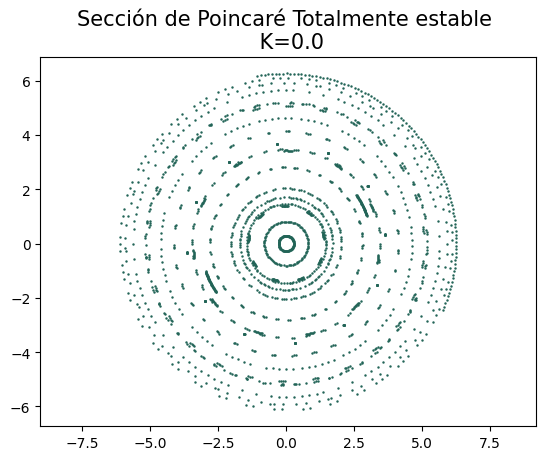

In [7]:
t=0

plt.figure()
plt.plot(chirikov[t][:,0], chirikov[t][:,1], '.', markersize=1.5, alpha=1, c='#226457')
plt.title(f'Sección de Poincaré Totalmente estable \n K={K_valores[t]}', fontsize=15)
plt.axis('equal')
plt.savefig(f'Sección de Poincare Totalmente estable \n K={K_valores[t]}.png',bbox_inches='tight')
plt.show()

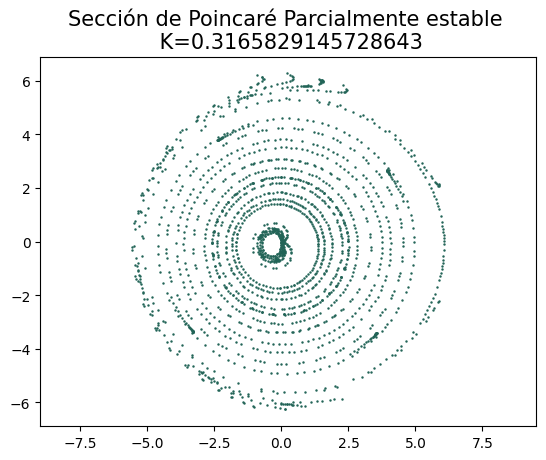

In [8]:
t=21

plt.figure()
plt.plot(muestras_modelo[t][:,:,0], muestras_modelo[t][:,:,1], '.', markersize=1.5, alpha=1, c='#226457')
plt.title(f'Sección de Poincaré Parcialmente estable \n K={K_valores[t]}', fontsize=15)
plt.axis('equal')
plt.savefig(f'Sección de Poincare Parcialmente estable \n K={K_valores[t]}.png',bbox_inches='tight')
plt.show()

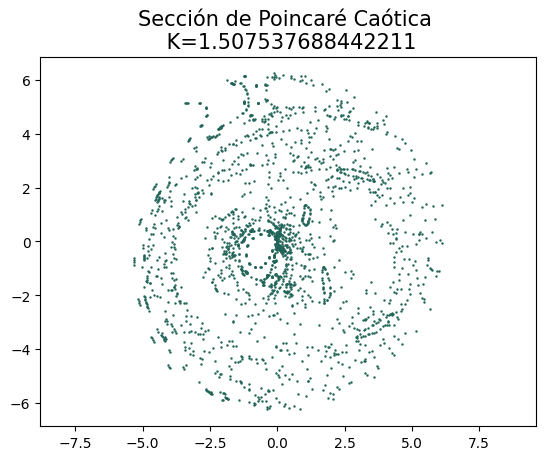

In [10]:
t=100

plt.figure()
plt.plot(muestras_modelo[t][:,:,0], muestras_modelo[t][:,:,1], '.', markersize=1.5, alpha=1, c='#226457')
plt.title(f'Sección de Poincaré Caótica \n K={K_valores[t]}', fontsize=15)
plt.axis('equal')
plt.savefig(f'Sección de Poincare Caótica \n K={K_valores[t]}.png',bbox_inches='tight')
plt.show()

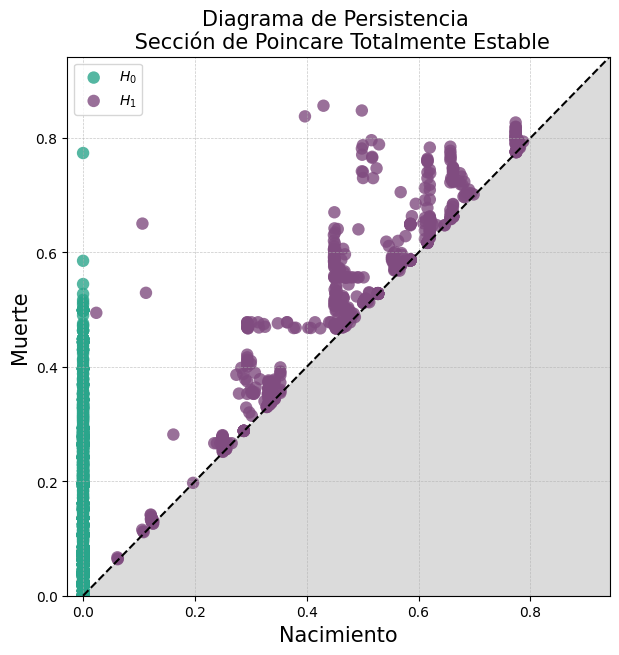

In [14]:
diag_CT_1=diagramas_persistencia[0]
graficar_diag(diag_CT_1, Titulo=f'Diagrama de Persistencia \n Sección de Poincare Totalmente Estable', guardado=f'Diag Sección de Poincare Totalmente estable')

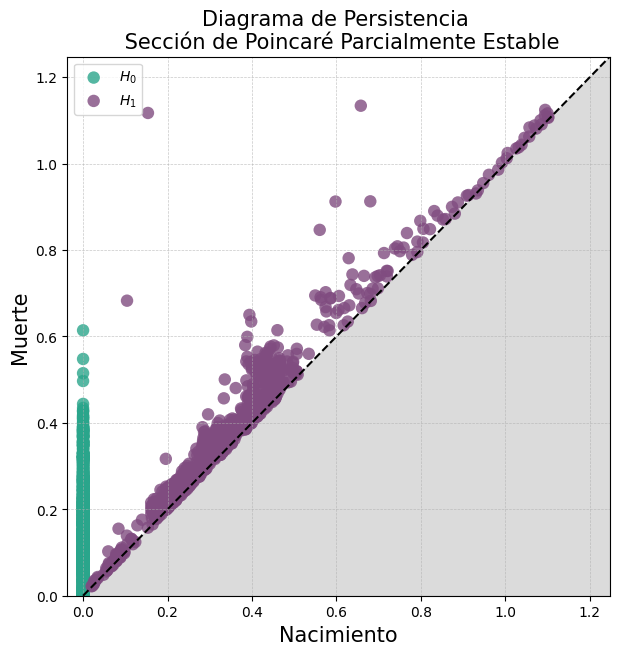

In [15]:
diag_CT_2=diagramas_persistencia[21]
graficar_diag(diag_CT_2, Titulo=f'Diagrama de Persistencia \n Sección de Poincaré Parcialmente Estable', guardado=f'Diag Sección de Poincare Parcialmente estable')

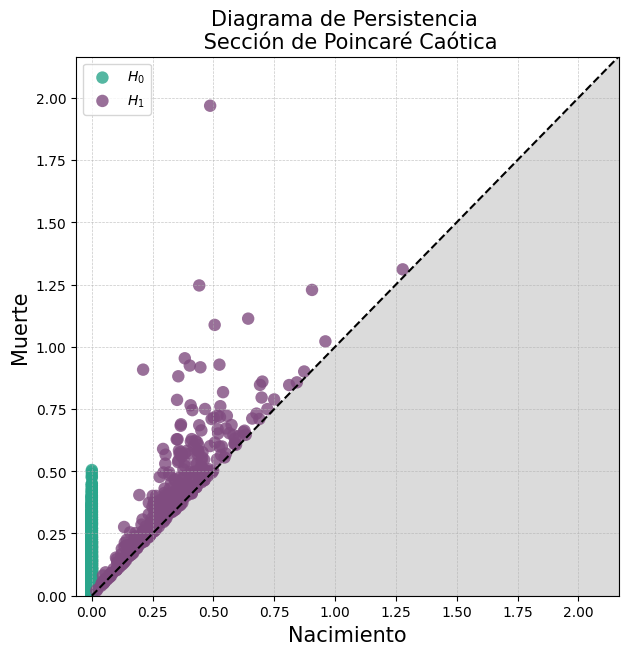

In [16]:
diag_CT_3=diagramas_persistencia[100]
graficar_diag(diag_CT_3, Titulo=f'Diagrama de Persistencia \n Sección de Poincaré Caótica', guardado=f'Diag Sección de Poincare Caotica')

# **Estimación de Caos (K)**

In [17]:
distancias=[]
for i in range(n):
    aux= persim.wasserstein(diagramas_persistencia[i][1], diag_referencia[1])
    distancias.append(aux)

<function matplotlib.pyplot.show(close=None, block=None)>

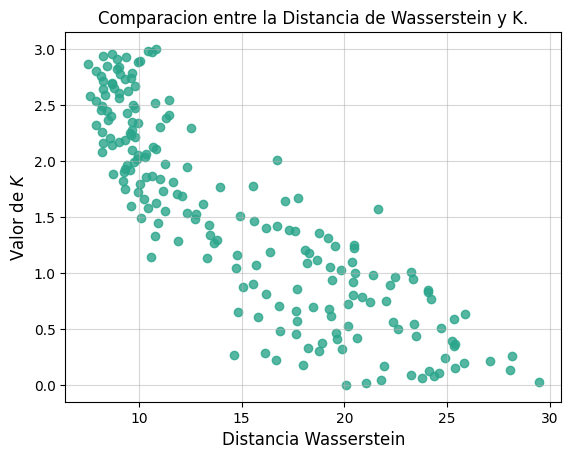

In [18]:
plt.figure()
plt.scatter(distancias, K_valores, color='#2AA58B', alpha=0.8)
plt.grid(True, alpha=0.5)
plt.title('Comparacion entre la Distancia de Wasserstein y K.')
plt.xlabel('Distancia Wasserstein', fontsize=12)
plt.ylabel('Valor de $K$', fontsize=12)
plt.savefig('Comparacion Wasserstein y K.png', bbox_inches='tight')
plt.show

RMSE promedio: 0.5272


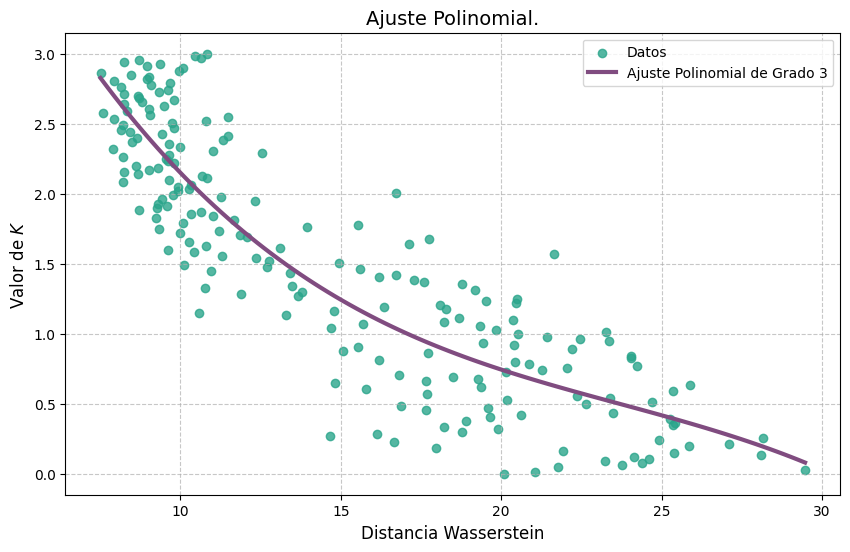

In [28]:
X = np.array(distancias).reshape(-1, 1)
y = np.array(K_valores)

modelo_final = entrenar_evaluar_polinomial(X, y, grado=3)

graficar_ajuste_polinomial(X, y, modelo_final, grado=3, titulo='Ajuste Polinomial.', eje_x='Distancia Wasserstein')

RMSE Global Segmentado: 0.3346


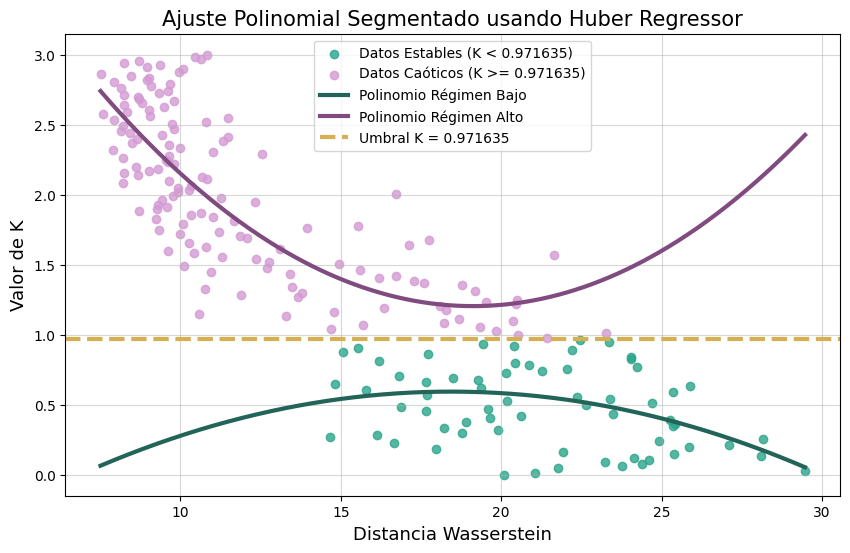

In [29]:
X = np.array(distancias).reshape(-1, 1)
y = np.array(K_valores)

mod_bajo, mod_alto = entrenar_modelo_segmentado(X, y)

evaluar_precision_global(X, y, mod_bajo, mod_alto, umbral_k=0.971635)

graficar_regresion_segmentada(X, y, mod_bajo, mod_alto, umbral_k=0.971635)

# **Prueba**

In [33]:
n=10
K_valores_prueba=np.linspace(0, 2, n)
num_puntos = 100
num_orbitas= 20

p_min,p_max=0,2*np.pi
theta_min,theta_max=0,2*np.pi

p_iniciales=[]
theta_iniciales=[]
for j in range(n):
  p_iniciales.append(np.random.uniform(p_min,p_max,num_orbitas))
  theta_iniciales.append(np.random.uniform(theta_min,theta_max,num_orbitas))

muestras_modelo=[]
for i in range(n):
    aux=sec_poincare(p_iniciales[i], theta_iniciales[i], K_valores_prueba[i], num_orbitas, num_puntos)
    muestras_modelo.append(aux)

diagramas_persistencia_prueba=[]
for i in range(n):
    puntos_para_homologia=np.concatenate(muestras_modelo[i], axis=0)
    aux=ripser(puntos_para_homologia, maxdim=1)['dgms']
    diagramas_persistencia_prueba.append(aux)

In [34]:
distancias_prueba=[]
for i in range(n):
    aux= persim.wasserstein(diagramas_persistencia_prueba[i][1], diag_referencia[1])
    distancias_prueba.append(aux)

In [35]:
tabla=comparar_predicciones_caos(distancias_prueba, K_valores_prueba, modelo_final, mod_bajo, mod_alto, umbral_k=0.971635)

tabla

,Sección de Poincaré,Distancia de Wasserstein,Predicción Usual,Predicción Segmentada,Estado Detectado,Valor de Caos Real
0,Sección 1,21.661566,0.6278,0.5475,Estable,0.000000
1,Sección 2,23.555822,0.5077,0.4773,Estable,0.222222
2,Sección 3,18.761337,0.8423,0.5932,Estable,0.444444
3,Sección 4,18.593274,0.8566,0.5935,Estable,0.666667
4,Sección 5,23.889091,0.4870,0.4617,Estable,0.888889
5,Sección 6,22.174162,0.5945,0.5316,Estable,1.111111
6,Sección 7,14.965663,1.2474,1.4007,Caótica,1.333333
7,Sección 8,11.010493,1.9218,1.9531,Caótica,1.555556
8,Sección 9,10.574935,2.0167,2.0358,Caótica,1.777778
9,Sección 10,9.806481,2.1956,2.1921,Caótica,2.000000
